<a href="https://colab.research.google.com/github/Komal2k4/Sentiment-analysis-using-LSTM/blob/main/Copy_of_Komal_DL%5BRNN%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.datasets import imdb #imdb is a movie review dataset used for sentiment analysis, label 1 represents a positive review and label 0 represents a negative review
from tensorflow.keras.preprocessing import sequence #sequence helps in handling sequence data (like padding)
import tensorflow as tf
import numpy as np
import pandas as pd

#Parameters
VOCAB_SIZE=88584 # considering 88584 unique words, total no.of unique words in the dataset
MAXLEN=250 #max length of each review is 250 words

#Load training data and testing data
(train_data,train_labels),(test_data,test_labels)=imdb.load_data(num_words=VOCAB_SIZE) #train_data --> training review(as sequence of numbers), train_labels -->training labels (0 or 1)
#imdb.load_data() --> loads preprocessed data where reviews are already converted into integer sequences.

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
train_data[0] #each number represents a word index, these word index is called as "token ID"

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 22665,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 21631,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 19193,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 10311,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 31050,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 12118,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5

**word --> index**

In [ ]:
#if we want to read the words, we need to convert the tokens[word indices] back to words.
#load the words to index mapping
word_index=imdb.get_word_index() #it returns a dictionary that maps word --> index[number]

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


**sort [word --> index] based on index**

In [ ]:
sorted=dict(sorted(word_index.items(),key=lambda item:item[1])) #sort based on item[1] (the index number).
#syntax:- sorted(iterable, key=some_function) where key --> rule for sorting

{'the': 1,
 'and': 2,
 'a': 3,
 'of': 4,
 'to': 5,
 'is': 6,
 'br': 7,
 'in': 8,
 'it': 9,
 'i': 10,
 'this': 11,
 'that': 12,
 'was': 13,
 'as': 14,
 'for': 15,
 'with': 16,
 'movie': 17,
 'but': 18,
 'film': 19,
 'on': 20,
 'not': 21,
 'you': 22,
 'are': 23,
 'his': 24,
 'have': 25,
 'he': 26,
 'be': 27,
 'one': 28,
 'all': 29,
 'at': 30,
 'by': 31,
 'an': 32,
 'they': 33,
 'who': 34,
 'so': 35,
 'from': 36,
 'like': 37,
 'her': 38,
 'or': 39,
 'just': 40,
 'about': 41,
 "it's": 42,
 'out': 43,
 'has': 44,
 'if': 45,
 'some': 46,
 'there': 47,
 'what': 48,
 'good': 49,
 'more': 50,
 'when': 51,
 'very': 52,
 'up': 53,
 'no': 54,
 'time': 55,
 'she': 56,
 'even': 57,
 'my': 58,
 'would': 59,
 'which': 60,
 'only': 61,
 'story': 62,
 'really': 63,
 'see': 64,
 'their': 65,
 'had': 66,
 'can': 67,
 'were': 68,
 'me': 69,
 'well': 70,
 'than': 71,
 'we': 72,
 'much': 73,
 'been': 74,
 'bad': 75,
 'get': 76,
 'will': 77,
 'do': 78,
 'also': 79,
 'into': 80,
 'people': 81,
 'other': 82,
 '

**index --> word**

In [ ]:
#create a reverse mapping from index to word and manually add special reserved tokens.
reverse_word_index={index+3:word for word,index in word_index.items()}
#add reverse_word_index reserved tokens manually
reverse_word_index[0]="<PAD>"
reverse_word_index[1]="<START>"
reverse_word_index[2]="<UNK>"
reverse_word_index[3]="<UNUSED>"

**decode review**

In [ ]:
decoded_review=" ".join([reverse_word_index.get(i,"?") for i in train_data[0]])
print(decoded_review)
print(train_labels[0])
#Note:- "?" is printed when a token index is not found in the reverse word dictionary

<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and sho

In [ ]:
decoded_review=" ".join([reverse_word_index.get(i,"?") for i in train_data[2]])
print(decoded_review)
print(train_labels[2])

<START> this has to be one of the worst films of the 1990s when my friends i were watching this film being the target audience it was aimed at we just sat watched the first half an hour with our jaws touching the floor at how bad it really was the rest of the time everyone else in the theatre just started talking to each other leaving or generally crying into their popcorn that they actually paid money they had earnt working to watch this feeble excuse for a film it must have looked like a great idea on paper but on film it looks like no one in the film has a clue what is going on crap acting crap costumes i can't get across how embarrasing this is to watch save yourself an hour a bit of your life
0


In [ ]:
len(train_data[0])
len(train_data[1])
len(train_data[2])

141

**Convert all inputs to fixed length**

In [ ]:
#to make our model understand the data easily we are converting all the inputs into fixed length
train_data=sequence.pad_sequences(train_data,MAXLEN)
test_data=sequence.pad_sequences(test_data,MAXLEN)

In [ ]:
train_data[1]

array([    0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     1,   194,
        1153,   194,  8255,    78,   228,     5,     6,  1463,  4369,
        5012,   134,    26,     4,   715,     8,   118,  1634,    14,
         394,    20,    13,   119,   954,   189,   102,     5,   207,
         110,  3103,    21,    14,    69,   188,     8,    30,    23,
           7,     4,   249,   126,    93,     4,   114,     9,  2300,
        1523,     5,   647,     4,   116,     9,    35,  8163,     4,
         229,     9,   340,  1322,     4,   118,     9,     4,   130,
        4901,    19,

In [ ]:
len(train_data[1])

250

**Build the model**

In [ ]:
model=tf.keras.Sequential([
    tf.keras.Input(shape=(MAXLEN,)), #shape=(MAXLEN,) --> ,[comma] represents a 1-Dimensional tuple without ,[comma] MAXLEN is considered as just a number
    tf.keras.layers.Embedding(VOCAB_SIZE,32),
    #tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.LSTM(32), #if you want to apply LSTM, just use LSTM inplace of RNN
    tf.keras.layers.Dense(1,activation="sigmoid")
])
#Note:- Embedding layer converts integer word indices into dense 32-dimensional vectors that capture semantic meaning
#Embedding captures semantic meaning --> words with similar meaning get similar vector representations

In [ ]:
model.summary()
#Note:- None is nothing but batch_size which we haven't defined in our code

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 32)        │     2,834,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,843,041 (10.85 MB)

 Trainable params: 2,843,041 (10.85 MB)

 Non-trainable params: 0 (0.00 B)

**compile the model**

In [ ]:
model.compile(
    optimizer="rmsprop", #rmsprop --> root mean square propagation
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
#Note:- rmsprop adjusts learning rate automatically, works well for sequence models like RNN and handles unstable gradients better.

**train the model**

In [ ]:
history=model.fit(train_data,train_labels,epochs=10,validation_split=0.2) #validation_split is used to validate the model
#Note:- validation_split=0.2 means where 80% of training data is used to train the model, rest of the 20% training data is used to check the performance of the model by validating(testing)
#output:- By observing the 10th epoch we can clearly say that our model is overfitting.

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.6610 - loss: 0.5858 - val_accuracy: 0.8288 - val_loss: 0.3893
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8831 - loss: 0.2919 - val_accuracy: 0.8794 - val_loss: 0.2945
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9161 - loss: 0.2165 - val_accuracy: 0.8820 - val_loss: 0.2882
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9314 - loss: 0.1864 - val_accuracy: 0.8878 - val_loss: 0.3002
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9449 - loss: 0.1567 - val_accuracy: 0.8780 - val_loss: 0.3214
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9496 - loss: 0.1402 - val_accuracy: 0.8872 - val_loss: 0.3192
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9593 - loss: 0.1112 - val_accuracy: 0.8822 - val_loss: 0.3230
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9685 - loss: 0.0964 - val_acc

In [ ]:
losses=pd.DataFrame(history.history) #.history is a dictionary
losses
#.history accesses the training results dictionary stored inside the history object.

,accuracy,loss,val_accuracy,val_loss
0,0.75970,0.481560,0.8288,0.389338
1,0.88455,0.289681,0.8794,0.294476
2,0.91145,0.227867,0.8820,0.288232
3,0.92985,0.190335,0.8878,0.300176
4,0.94205,0.161502,0.8780,0.321368
5,0.94870,0.142072,0.8872,0.319164
6,0.95610,0.121995,0.8822,0.323014
7,0.96635,0.102953,0.8822,0.359240
8,0.97080,0.089990,0.8812,0.325633
9,0.97565,0.075184,0.8844,0.343517


<Axes: >

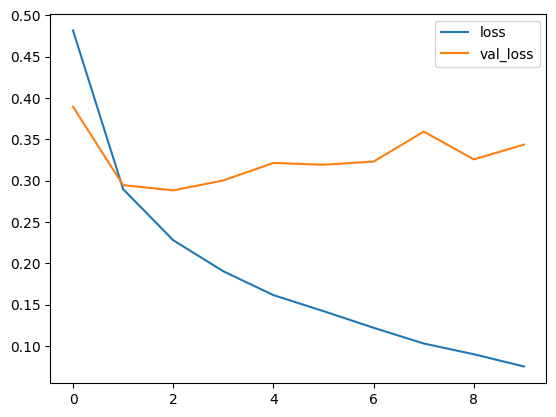

In [ ]:
losses[["loss","val_loss"]].plot()

<Axes: >

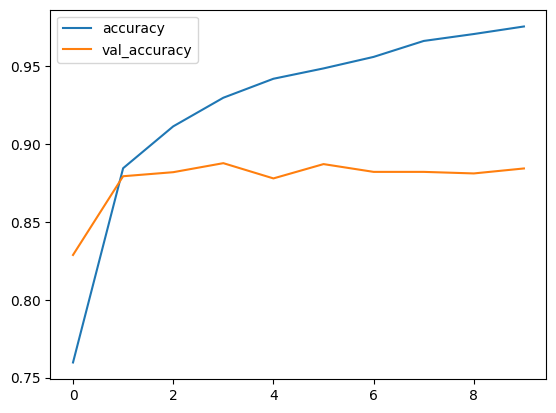

In [ ]:
losses[["accuracy","val_accuracy"]].plot()

In [ ]:
model.save("rnn.h5")

In [ ]:
new_model=tf.keras.models.load_model("rnn.h5")

**evaluate the model**

In [ ]:
results=new_model.evaluate(test_data,test_labels)
print(results)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8682 - loss: 0.3928
[0.38833197951316833, 0.8691999912261963]


In [ ]:
decoded_review=" ".join([reverse_word_index.get(i,"?") for i in test_data[0]])
print("\nDecoded Review:\n")
print(decoded_review)


Decoded Review:

<PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD

In [ ]:
print("\nActual Label:",test_labels[0])


Actual Label: 0


**make prediction**

In [ ]:
prediction=model.predict(np.array([test_data[0]]))
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step


array([[0.03693286]], dtype=float32)

In [ ]:
#convert to binary
predicted_label=1 if prediction[0][0] > 0.5 else 0
predicted_label
#Note:- we use [0][0] to access the actual prediction value inside the 2D output array.

0